In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random

from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniforge/base/envs/tf-mac/bin/python


In [ ]:
# ── 0. Download dataset from kaggle ──────────────────────────────────────────────────────────────────
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

100%|██████████| 157M/157M [00:08<00:00, 18.9MB/s] 

Extracting model files...


Path to dataset files: /Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [4]:
import os 
os.listdir("/Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2")

['Training', 'Testing']

In [3]:
# ── 1. Paths ──────────────────────────────────────────────────────────────────

train_path = "/Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training"
test_path = "/Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing"

classes = os.listdir(train_path)
print('Classes: ', classes)

Classes:  ['pituitary', 'notumor', 'glioma', 'meningioma']


In [4]:
# ── 2. Dataset info ───────────────────────────────────────────────────────────
data_info = []
for cls in classes:
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    data_info.append([cls, train_count, test_count])

df = pd.DataFrame(data_info, columns=["Class", "Train Count", "Test Count"])
print(df)

        Class  Train Count  Test Count
0   pituitary         1400         400
1     notumor         1400         400
2      glioma         1400         400
3  meningioma         1400         400


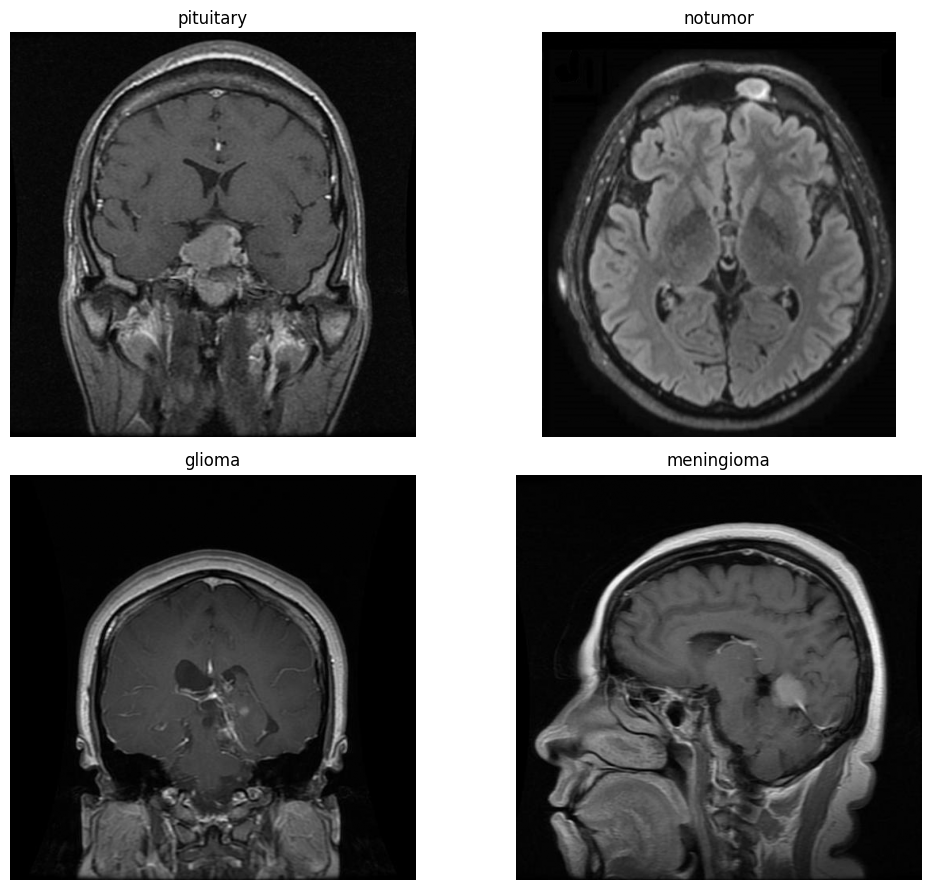

In [5]:
# ── 2. Dataset info (visually) ────────────────────────────────────────────────
import random

plt.figure(figsize=(11, 9))
for i, cls in enumerate(classes):
    img_path = os.path.join(train_path, cls, random.choice(os.listdir(os.path.join(train_path, cls))))
    img = cv2.imread(img_path, 0)

    plt.subplot(2, 2, i+1)
    plt.imshow(img, 'gray')
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# ── 3. Sample image sizes ─────────────────────────────────────────────────────

sizes = []
for cls in classes:
    img_path = os.path.join(train_path, cls, os.listdir(os.path.join(train_path, cls))[0])
    img = cv2.imread(img_path, 0)
    sizes.append(img.shape)

print(sizes)

[(512, 512), (251, 201), (512, 512), (512, 512)]


In [7]:
# ── 4. Crop helper ────────────────────────────────────────────────────────────
import imutils 

def crop_img(img):
    """
    Finds the extreme points on the image and crops the rectangular region out of them.
    Expects a BGR image (as returned by cv2.imread).
    """
    # FIX: use COLOR_BGR2GRAY (not COLOR_RGB2GRAY) because cv2.imread returns BGR
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh,  None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    extLeft  = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop   = tuple(c[c[:, :, 1].argmin()][0])
    extBot   = tuple(c[c[:, :, 1].argmax()][0])

    new_img = img[extTop[1]:extBot[1], extLeft[0]:extRight[0]].copy()
    return new_img

ModuleNotFoundError: No module named 'imutils'

In [26]:
import os
import gc
from tqdm import tqdm

IMG_SIZE = 256

training = "/Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training"
testing = "/Users/Ahmad/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing"

base_output = "datasets/cropped"

def process_folder(source_path, output_path):
    classes = os.listdir(source_path)

    for cls in classes:
        class_path = os.path.join(source_path, cls)
        save_path = os.path.join(output_path, cls)

        os.makedirs(save_path, exist_ok=True)

        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            image = cv2.imread(img_path)
            if image is None:
                continue

            new_img = crop_img(image)
            new_img = cv2.resize(new_img, (IMG_SIZE, IMG_SIZE))

            cv2.imwrite(os.path.join(save_path, img_name), new_img)

            del image
            del new_img

        gc.collect()


process_folder(training, os.path.join(base_output, "Training"))
process_folder(testing, os.path.join(base_output, "Testing"))

100%|██████████| 400/400 [00:00<00:00, 884.49it/s]


In [8]:
os.listdir("datasets/cropped/Testing")

['pituitary', 'notumor', 'glioma', 'meningioma']

In [9]:
os.listdir("datasets/cropped/Training")

['pituitary', 'notumor', 'glioma', 'meningioma']

In [10]:
# ── 4. Demo: Crop helper ──────────────────────────────────────────────────────
import os
import cv2
import imutils

target_class = 'meningioma'
class_path = os.path.join("datasets/cropped/Training", target_class)
image_files_in_class = os.listdir(class_path)

if not image_files_in_class:
    raise ValueError(f"No images found in the directory: {class_path}")

selected_img_filename = image_files_in_class[0]
img_path_to_load = os.path.join(class_path, selected_img_filename)

img = cv2.imread(img_path_to_load)

if img is None:
    raise ValueError(f"Failed to load image from path: {img_path_to_load}. The file might not exist or be corrupted.")

img = cv2.resize(
            img,
            dsize=(224,224),
            interpolation=cv2.INTER_CUBIC
        )
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)

# threshold the image, then perform a series of erosions +
# dilations to remove any small regions of noise
thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
thresh = cv2.erode(thresh, None, iterations=2)
thresh = cv2.dilate(thresh, None, iterations=2)

# find contours in thresholded image, then grab the largest one
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)

# find the extreme points
extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
extTop = tuple(c[c[:, :, 1].argmin()][0])
extBot = tuple(c[c[:, :, 1].argmax()][0])

# add contour on the image
img_cnt = cv2.drawContours(img.copy(), [c], -1, (0, 255, 255), 4)

# add extreme points
img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

# crop
ADD_PIXELS = 0
new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

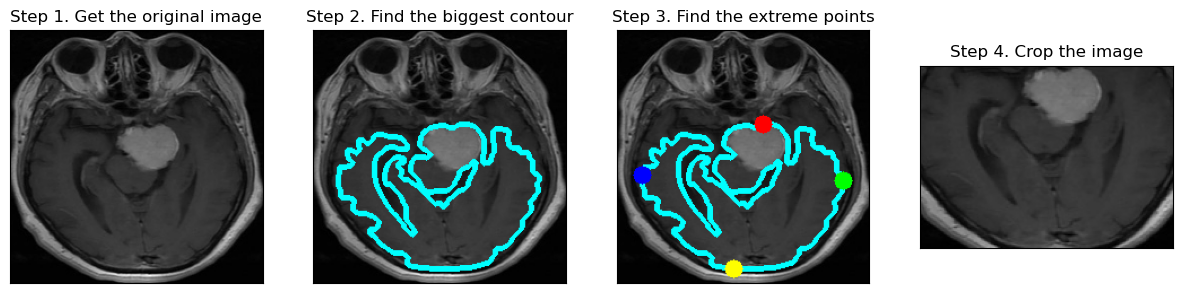

In [11]:
plt.figure(figsize=(15,6))
plt.subplot(141)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Step 1. Get the original image')
plt.subplot(142)
plt.imshow(img_cnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 2. Find the biggest contour')
plt.subplot(143)
plt.imshow(img_pnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 3. Find the extreme points')
plt.subplot(144)
plt.imshow(new_img)
plt.xticks([])
plt.yticks([])
plt.title('Step 4. Crop the image')
plt.show()

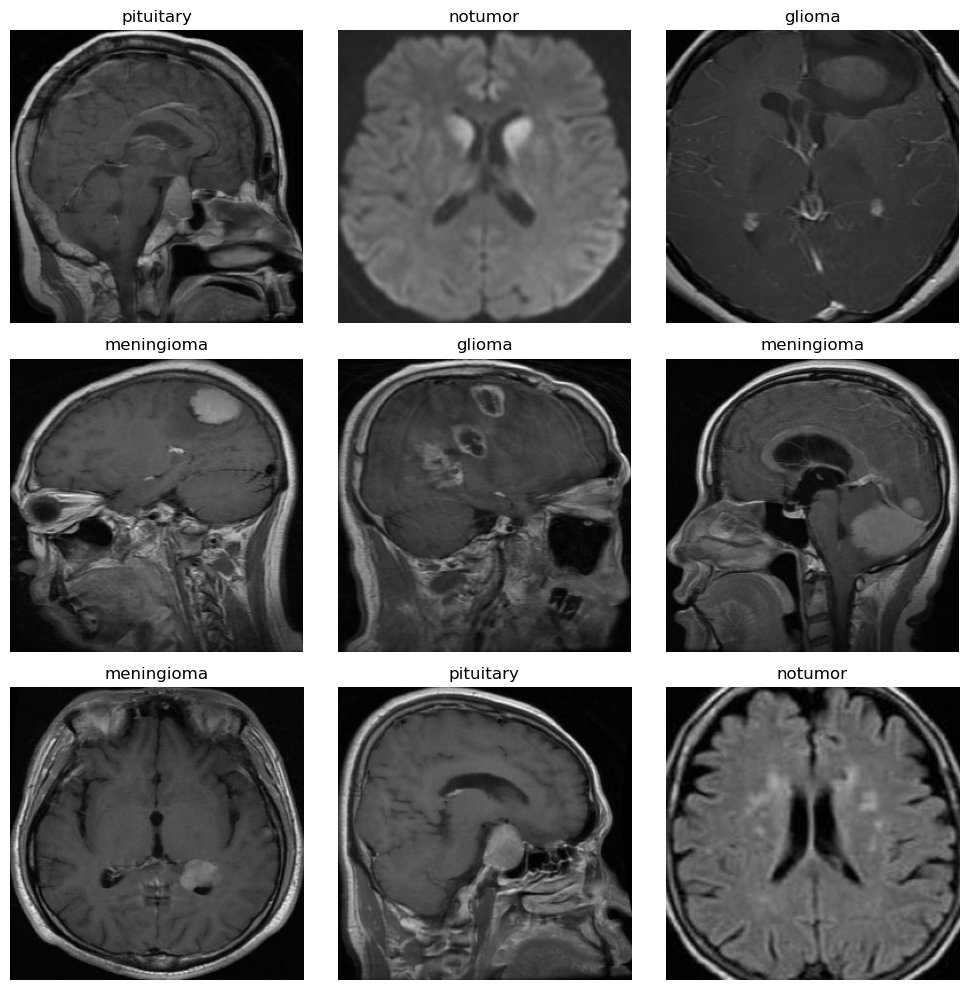

In [3]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Show a 3x3 grid of random cropped training images
base_dir = "datasets/cropped/Training"
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

sample_paths = []
for cls in classes:
    cls_dir = os.path.join(base_dir, cls)
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if imgs:
        sample_paths.append(os.path.join(cls_dir, random.choice(imgs)))

# If fewer than 9 classes/images, fill randomly from all images
all_imgs = []
for cls in classes:
    cls_dir = os.path.join(base_dir, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_imgs.append(os.path.join(cls_dir, f))

while len(sample_paths) < 9 and all_imgs:
    sample_paths.append(random.choice(all_imgs))

sample_paths = sample_paths[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(os.path.dirname(img_path)))
    ax.axis('off')

# Hide any leftover axes if fewer than 9 images
for ax in axes[len(sample_paths):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [10]:
X_train = []
y_train = []
X_test = []
y_test = []
image_size = 200
labels = ['glioma','meningioma','notumor','pituitary'] 
for i in labels:
    folderpath = os.path.join('datasets/cropped/Training',i)
    for j in os.listdir(folderpath):
        image = cv2.imread(os.path.join(folderpath,j),0) #load images in gray
        image = cv2.bilateralFilter(image,2,50,50) # remove noise image
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE) # produce a pseudocolored image.
        image = cv2.resize(image, (image_size, image_size)) # resize images
        X_train.append(image)
        y_train.append(labels.index(i))
        
for i in labels:
    folderpath = os.path.join('datasets/cropped/Testing',i)
    for j in os.listdir(folderpath):
        image = cv2.imread(os.path.join(folderpath,j),0) #load images in gray
        image = cv2.bilateralFilter(image,2,50,50) # remove noise image
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE) # produce a pseudocolored image.
        image = cv2.resize(image, (image_size, image_size)) # resize images
        X_test.append(image)
        y_test.append(labels.index(i))

X_train = np.array(X_train) / 255.0 # normalize Images into range 0 to 1.
X_test = np.array(X_test) / 255.0

print(X_train.shape)
print(X_test.shape)

(5600, 200, 200, 3)
(1600, 200, 200, 3)


In [11]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [12]:
X_train, y_train = shuffle(X_train,y_train, random_state=42) 

In [13]:
# One Hot Encoding on the labels
y_train = tf.keras.utils.to_categorical(y_train) 
y_test = tf.keras.utils.to_categorical(y_test)

In [14]:
#Dividing the dataset into Training and Validation sets.

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42) 
print(X_val.shape)
print(X_train.shape)
print(X_test.shape)

class_counts_train = np.sum(y_train, axis=0)
class_counts_val = np.sum(y_val, axis=0)
class_counts_test = np.sum(y_test, axis=0)

print("Training set class counts:")
print(class_counts_train)

print("\nValidation set class counts:")
print(class_counts_val)

print("\nTesting set class counts:")
print(class_counts_test)

(1120, 200, 200, 3)
(4480, 200, 200, 3)
(1600, 200, 200, 3)
Training set class counts:
[1087. 1131. 1133. 1129.]

Validation set class counts:
[313. 269. 267. 271.]

Testing set class counts:
[400. 400. 400. 400.]


Image Augmentation

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.optimizers import Adam

In [16]:
# ImageDataGenerator transforms each image in the batch by a series of random translations, rotations, etc.
datagen = ImageDataGenerator(
     rotation_range=10,                        
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True)

# After you have created and configured your ImageDataGenerator, you must fit it on your data.
datagen.fit(X_train)

MODEL TRAINING

In [17]:
from tensorflow.keras.applications.resnet import ResNet50
IMG_SIZE=(200,200)
base_model = ResNet50(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights='imagenet')

for layer in base_model.layers:
    layer.trainable = True

# Customized layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
predict = Dense(4,activation='softmax')(x)

# create a model object
model = Model(inputs = base_model.input,outputs = predict)

#compile our model.
adam = Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss = 'categorical_crossentropy', metrics=['accuracy'])

train_len = len(X_train)
val_len = len(X_val)
print("-----------Training Data length-----------------")
print(train_len)

print("-----------Validation Data length-----------------")
print(val_len)

hist = model.fit(datagen.flow(X_train, y_train, batch_size=32),validation_data = (X_val,y_val),epochs = 25,verbose=1)

# ---- Save model ----
os.makedirs('models/trained', exist_ok=True)
model.save('models/trained/brain_tumor_MRI_resnet50.keras')


2026-03-11 16:34:12.038149: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-11 16:34:12.041173: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-11 16:34:12.041724: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-11 16:34:12.042190: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-11 16:34:12.042991: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


-----------Training Data length-----------------
4480
-----------Validation Data length-----------------
1120
Epoch 1/25


2026-03-11 16:34:17.270481: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-11 16:34:17.825705: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


140/140 [==============================] - 103s 674ms/step - loss: 0.3249 - accuracy: 0.8819 - val_loss: 3.2961 - val_accuracy: 0.2196
Epoch 2/25
140/140 [==============================] - 95s 677ms/step - loss: 0.1153 - accuracy: 0.9583 - val_loss: 7.0922 - val_accuracy: 0.2795
Epoch 3/25
140/140 [==============================] - 109s 782ms/step - loss: 0.0713 - accuracy: 0.9770 - val_loss: 6.2146 - val_accuracy: 0.2830
Epoch 4/25
140/140 [==============================] - 114s 815ms/step - loss: 0.0488 - accuracy: 0.9835 - val_loss: 2.9448 - val_accuracy: 0.3152
Epoch 5/25
140/140 [==============================] - 120s 856ms/step - loss: 0.0337 - accuracy: 0.9904 - val_loss: 6.1901 - val_accuracy: 0.4045
Epoch 6/25
140/140 [==============================] - 117s 836ms/step - loss: 0.0300 - accuracy: 0.9911 - val_loss: 2.2431 - val_accuracy: 0.5536
Epoch 7/25
140/140 [==============================] - 116s 831ms/step - loss: 0.0429 - accuracy: 0.9882 - val_loss: 0.5343 - val_accurac

In [19]:
from keras.models import load_model
model = load_model('models/trained/brain_tumor_MRI_resnet50.keras')

Text(0.5, 1.0, 'Training and Validation Loss')

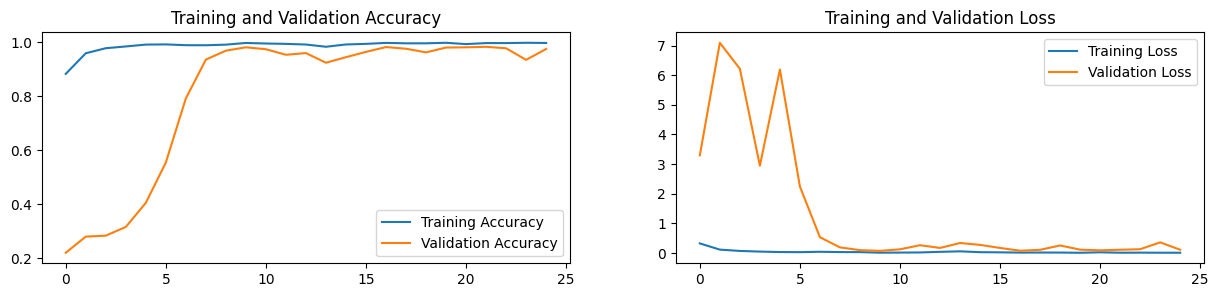

In [20]:
#Plotting the results
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

plt.figure(figsize=(15,3))
plt.subplot(1,2,1)
plt.plot(acc,label='Training Accuracy')
plt.plot(val_acc,label='Validation Accuracy')
plt.legend(loc= "lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label='Training Loss')
plt.plot(val_loss,label='Validation Loss')
plt.legend(loc= "upper right")
plt.title("Training and Validation Loss")

Validation on Test set

In [21]:
loss,acc = model.evaluate(X_test,y_test)

50/50 [==============================] - 9s 159ms/step - loss: 0.4432 - accuracy: 0.9425


In [22]:
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import confusion_matrix

predicted_classes = np.argmax(model.predict(X_test), axis = 1)
print(classification_report(np.argmax(y_test,axis=1), predicted_classes,target_names=['glioma','meningioma','no_tumor','pituitary']))

50/50 [==============================] - 10s 163ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       400
  meningioma       0.88      0.96      0.92       400
    no_tumor       0.96      1.00      0.98       400
   pituitary       0.95      0.98      0.97       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



200/200 [==============================] - 9s 44ms/step


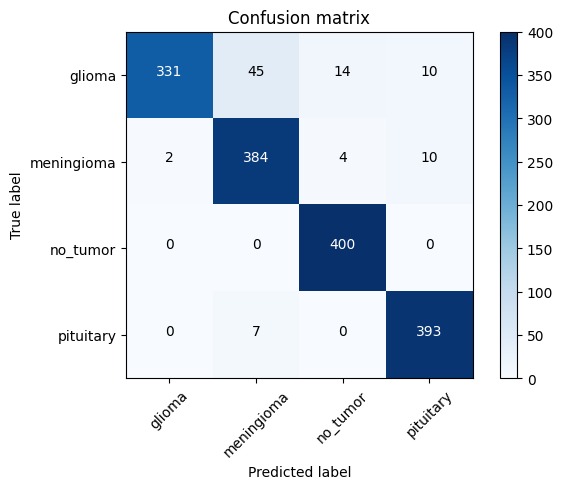

In [23]:
import itertools
import seaborn as sns
pred_Y = model.predict(X_test, batch_size = 8, verbose = True)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    target_names=['glioma','meningioma','no_tumor','pituitary']

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
Y_pred = model.predict(X_test, batch_size=8)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(pred_Y,axis = 1) 
# Convert validation observations to one hot vectors
# compute the confusion matrix
rounded_labels=np.argmax(y_test, axis=1)
confusion_mtx = confusion_matrix(rounded_labels, Y_pred_classes)

 

# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(4))

In [27]:
from sklearn.metrics import roc_auc_score

y_probs = model.predict(X_test)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')

print(f"Multiclass ROC AUC Score (One-vs-Rest): {auc_score:.4f}")

50/50 [==============================] - 8s 162ms/step
Multiclass ROC AUC Score (One-vs-Rest): 0.9924
